# Centrix LASSO Centroiding — Step-by-Step Walkthrough

This notebook demonstrates how the **Centrix centroider** works, step by step.
Centrix replaces the onboard centroiding of the Thermo Stellar linear ion trap
using **non-negative LASSO regression** with Gaussian basis functions.

**The problem:** The Stellar's onboard centroider places ~1 centroid per Da.
When two signals fall within 1 Da of each other (common in DIA), they collapse
into a single incorrect centroid. Centrix deconvolutes these overlapping signals.

**The solution:** Model the profile signal as a sparse sum of Gaussians:

$$y(m/z) = \sum_j \beta_j \cdot \exp\!\left(-\frac{(m/z - g_j)^2}{2\sigma^2}\right) + \varepsilon$$

and solve via non-negative LASSO:

$$\min_{\beta \geq 0} \;\frac{1}{2}\|y - A\beta\|^2 + \lambda\|\beta\|_1$$

Each non-zero $\beta_j$ corresponds to a detected centroid at grid position $g_j$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
from matplotlib.collections import LineCollection

%matplotlib inline
plt.rcParams.update({
    'figure.figsize': (14, 5),
    'font.size': 12,
    'axes.grid': True,
    'grid.alpha': 0.3,
})

## Simulate a Profile Mass Spectrum

We create a synthetic MS2 spectrum mimicking the Thermo Stellar at 125 kTh/s scan rate:
- **Grid spacing:** 1/8 = 0.125 Th (firmware-fixed for MS2)
- **Peak σ:** 0.340 Da (125 kTh/s FWHM ≈ 0.8 Da)
- **Three peaks**, two of which are only **0.5 Da apart** — the scenario Centrix is designed to solve

In [2]:
# Instrument parameters (Stellar MS2 at 125 kTh/s)
SIGMA = 0.340       # Gaussian σ in Da
GRID_SPACING = 0.125 # Profile grid spacing (1/8 Th for MS2)

# True peak positions and amplitudes
true_peaks = [
    (500.00, 8000.0),   # Peak A
    (500.50, 5000.0),   # Peak B — only 0.5 Da from A (< 1 Da overlap!)
    (503.25, 12000.0),  # Peak C — well-separated
]

# Generate profile data on a uniform grid
mz = np.arange(498.0, 506.0, GRID_SPACING)
n_pts = len(mz)

# Sum of Gaussians + noise
np.random.seed(42)
noise_level = 50.0
signal = np.zeros(n_pts)
for center, amplitude in true_peaks:
    signal += amplitude * np.exp(-0.5 * ((mz - center) / SIGMA) ** 2)
intensity = signal + np.random.normal(0, noise_level, n_pts)
intensity = np.maximum(intensity, 0)  # no negative intensities

print(f"Profile: {n_pts} data points, {mz[0]:.1f}–{mz[-1]:.1f} m/z")
print(f"True peaks: {[f'{c:.2f} Da ({a:.0f})' for c, a in true_peaks]}")

Profile: 64 data points, 498.0–505.9 m/z
True peaks: ['500.00 Da (8000)', '500.50 Da (5000)', '503.25 Da (12000)']


## Visualize the Raw Profile Spectrum

This is what the instrument outputs in profile mode. Note how peaks A and B
(0.5 Da apart) appear as a **single merged hump** — the onboard Thermo centroider
would place one centroid somewhere between them, losing both true positions.

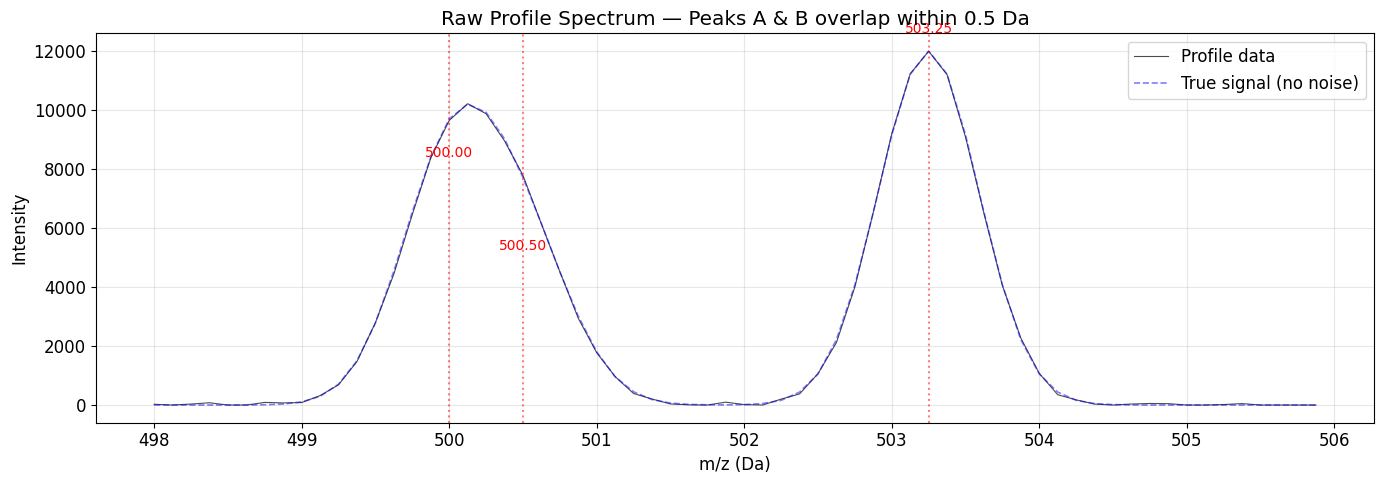

In [3]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(mz, intensity, 'k-', lw=0.8, alpha=0.7, label='Profile data')
ax.plot(mz, signal, 'b--', lw=1.2, alpha=0.5, label='True signal (no noise)')

for center, amplitude in true_peaks:
    ax.axvline(center, color='red', ls=':', alpha=0.5)
    ax.annotate(f'{center:.2f}', xy=(center, amplitude * 1.05),
                ha='center', fontsize=10, color='red')

ax.set_xlabel('m/z (Da)')
ax.set_ylabel('Intensity')
ax.set_title('Raw Profile Spectrum — Peaks A & B overlap within 0.5 Da')
ax.legend()
plt.tight_layout()
plt.show()

## Step 1: Noise Estimation

Centrix uses a fast **order-statistics** approach:
- **Baseline:** 10th percentile of sorted intensities
- **Noise σ:** IQR / 1.349 (robust Gaussian σ estimator)
- **Signal threshold:** baseline + N × noise_σ (default N = 3)

Baseline:    0.0
Noise σ:     3328.5
Threshold:   9985.5  (baseline + 3.0×σ)


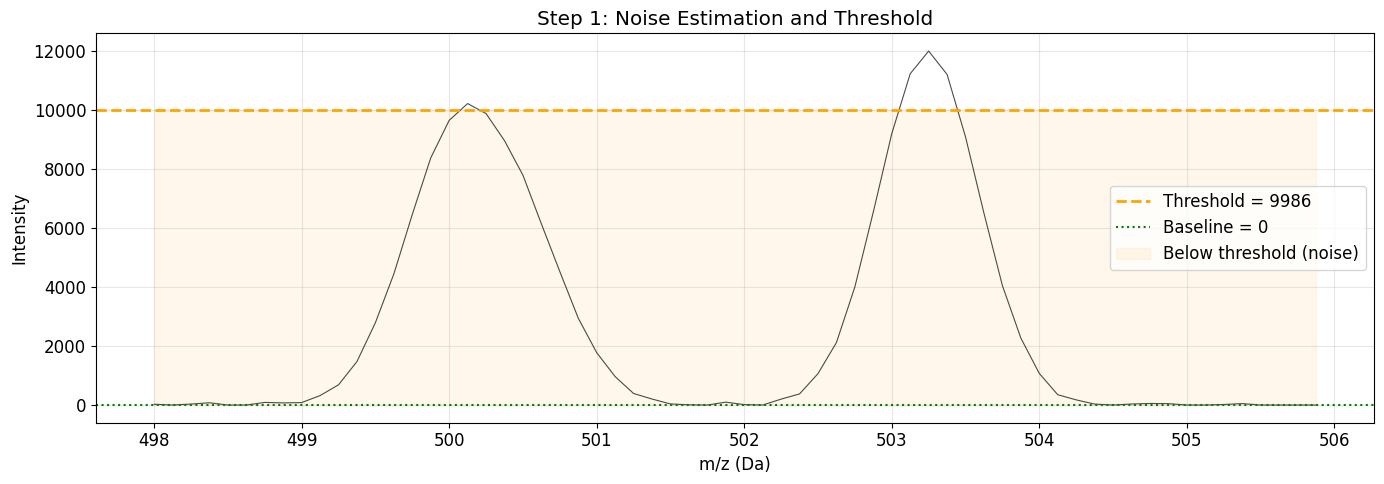

In [4]:
def rough_noise_estimate(intensity):
    """Centrix rough noise estimation (matches src/noise.rs)."""
    sorted_i = np.sort(intensity)
    n = len(sorted_i)
    baseline = sorted_i[int(0.10 * n)]  # 10th percentile
    q25 = sorted_i[int(0.25 * n)]
    q75 = sorted_i[int(0.75 * n)]
    noise_sigma = (q75 - q25) / 1.349   # IQR-based robust σ
    noise_sigma = max(noise_sigma, max(0.10 * baseline, 1.0))  # floor
    return float(baseline), float(noise_sigma)

SIGNAL_THRESHOLD_SIGMA = 3.0  # default
baseline, noise_sigma = rough_noise_estimate(intensity)
threshold = baseline + SIGNAL_THRESHOLD_SIGMA * noise_sigma

print(f"Baseline:    {baseline:.1f}")
print(f"Noise σ:     {noise_sigma:.1f}")
print(f"Threshold:   {threshold:.1f}  (baseline + {SIGNAL_THRESHOLD_SIGMA}×σ)")

# Visualize
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(mz, intensity, 'k-', lw=0.8, alpha=0.7)
ax.axhline(threshold, color='orange', ls='--', lw=2, label=f'Threshold = {threshold:.0f}')
ax.axhline(baseline, color='green', ls=':', lw=1.5, label=f'Baseline = {baseline:.0f}')
ax.fill_between(mz, 0, threshold, alpha=0.08, color='orange', label='Below threshold (noise)')
ax.set_xlabel('m/z (Da)')
ax.set_ylabel('Intensity')
ax.set_title('Step 1: Noise Estimation and Threshold')
ax.legend()
plt.tight_layout()
plt.show()

## Step 2: Signal Region Detection

Find contiguous stretches of above-threshold data, then:
1. **Merge** segments separated by ≤ 2 points (bridge small valleys)
2. **Extend** each region by 3 points on each side (capture tails)
3. **Filter** regions narrower than 3 points

Every detected region goes through LASSO — no fast-path shortcuts.

In [5]:
def detect_signal_regions(mz, intensity, threshold,
                          merge_gap=2, extension=3, min_width=3):
    """Detect signal regions (matches src/signal.rs)."""
    above = intensity > threshold
    n = len(mz)

    # Find contiguous above-threshold segments
    segments = []
    in_seg = False
    for i in range(n):
        if above[i] and not in_seg:
            seg_start = i
            in_seg = True
        elif not above[i] and in_seg:
            segments.append((seg_start, i - 1))
            in_seg = False
    if in_seg:
        segments.append((seg_start, n - 1))

    if not segments:
        return []

    # Merge segments separated by ≤ merge_gap points
    merged = [segments[0]]
    for s, e in segments[1:]:
        if s <= merged[-1][1] + merge_gap + 1:
            merged[-1] = (merged[-1][0], e)
        else:
            merged.append((s, e))

    # Extend, clamp, filter
    regions = []
    for s, e in merged:
        s2 = max(0, s - extension)
        e2 = min(n - 1, e + extension)
        if e2 - s2 + 1 >= min_width:
            regions.append((s2, e2))
    return regions

regions = detect_signal_regions(mz, intensity, threshold)
print(f"Found {len(regions)} signal regions:")
for i, (s, e) in enumerate(regions):
    print(f"  Region {i}: indices [{s}..{e}], "
          f"m/z [{mz[s]:.3f}..{mz[e]:.3f}], "
          f"width {mz[e]-mz[s]:.3f} Da, "
          f"{e-s+1} points")

Found 2 signal regions:
  Region 0: indices [14..20], m/z [499.750..500.500], width 0.750 Da, 7 points
  Region 1: indices [38..46], m/z [502.750..503.750], width 1.000 Da, 9 points


### Visualize Detected Regions

Each colored region will be independently processed by the LASSO solver.

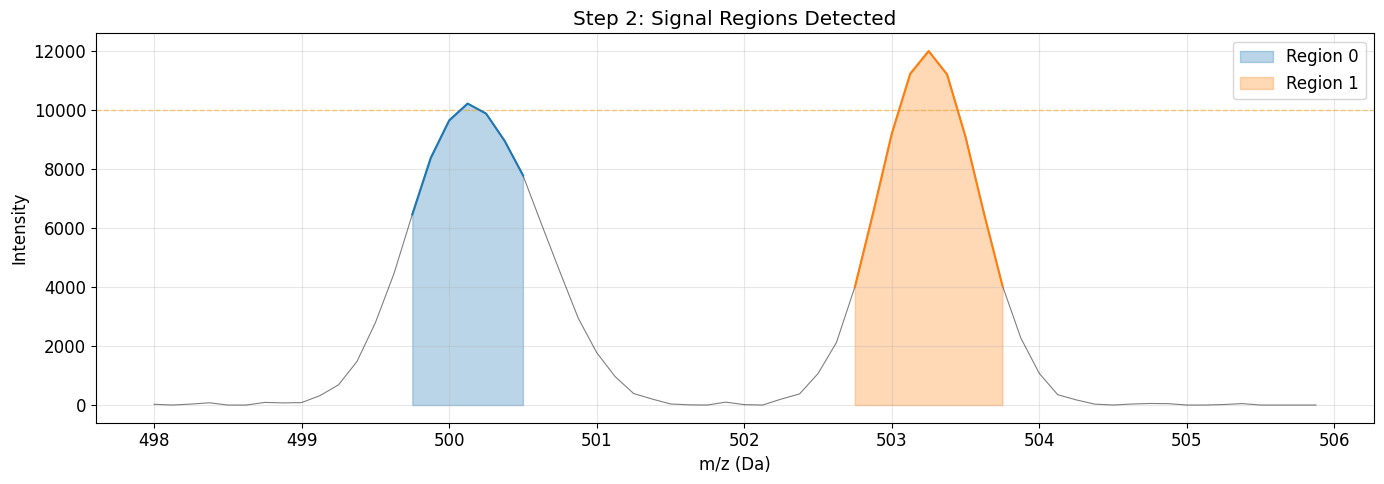

In [6]:
colors = plt.cm.tab10.colors

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(mz, intensity, 'k-', lw=0.8, alpha=0.5)
ax.axhline(threshold, color='orange', ls='--', lw=1, alpha=0.5)

for i, (s, e) in enumerate(regions):
    color = colors[i % len(colors)]
    ax.fill_between(mz[s:e+1], 0, intensity[s:e+1],
                    alpha=0.3, color=color, label=f'Region {i}')
    ax.plot(mz[s:e+1], intensity[s:e+1], '-', color=color, lw=1.5)

ax.set_xlabel('m/z (Da)')
ax.set_ylabel('Intensity')
ax.set_title('Step 2: Signal Regions Detected')
ax.legend()
plt.tight_layout()
plt.show()

## Step 3: Build the Gaussian Basis Matrix

For each region, Centrix builds a design matrix **A** where each column is a
Gaussian basis function centered at a grid position:

$$A_{i,j} = \exp\!\left(-\frac{(m/z_i - g_j)^2}{2\sigma^2}\right)$$

The grid uses the same spacing as the profile data (0.125 Da for MS2), so the
system is square or near-square. Let's examine the overlapping region (peaks A & B).

Region 0: 7 data points, 9 basis functions
Design matrix A: shape (7, 9)


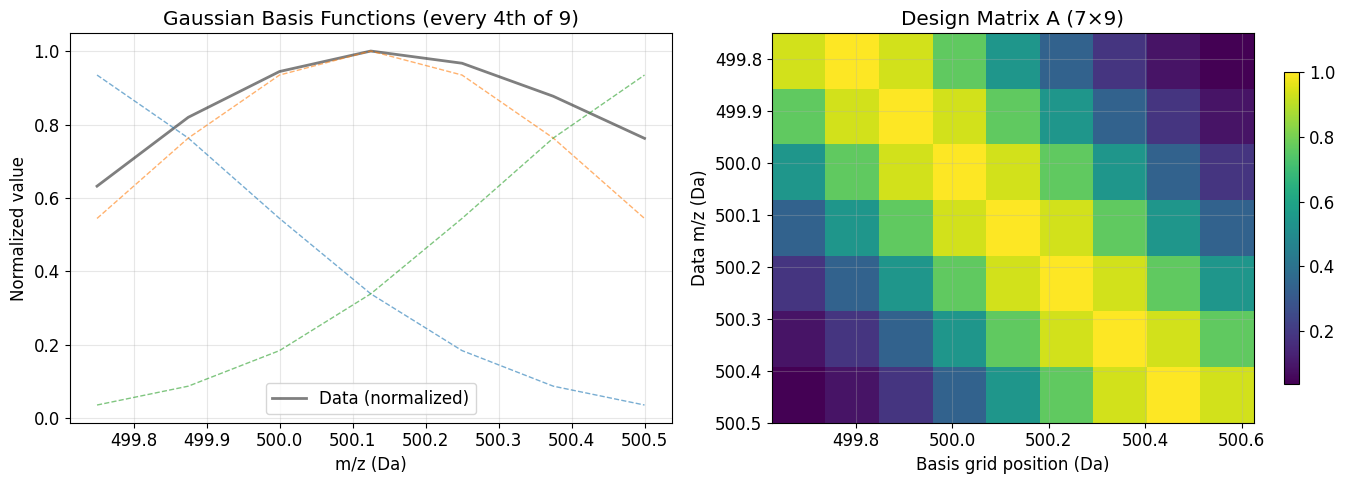

In [7]:
def build_grid(mz_start, mz_end, spacing):
    """Build grid positions covering [mz_start, mz_end] (matches src/basis.rs)."""
    k_start = int(np.floor(mz_start / spacing)) - 1
    positions = []
    k = k_start
    while True:
        pos = k * spacing
        if pos > mz_end + spacing:
            break
        if pos >= mz_start - spacing:
            positions.append(pos)
        k += 1
    return np.array(positions)

def build_design_matrix(mz_data, grid, sigma):
    """Build A[i,j] = exp(-(mz[i] - grid[j])² / (2σ²)) (matches src/basis.rs)."""
    inv_2sig2 = -1.0 / (2.0 * sigma * sigma)
    n_data = len(mz_data)
    n_basis = len(grid)
    A = np.zeros((n_data, n_basis))
    for j in range(n_basis):
        d = mz_data - grid[j]
        A[:, j] = np.exp(d * d * inv_2sig2)
    return A

# Focus on the overlapping region (region 0: peaks A & B)
r0_s, r0_e = regions[0]
mz_region = mz[r0_s:r0_e+1]
int_region = intensity[r0_s:r0_e+1]

grid = build_grid(mz_region[0], mz_region[-1], GRID_SPACING)
A = build_design_matrix(mz_region, grid, SIGMA)

print(f"Region 0: {len(mz_region)} data points, {len(grid)} basis functions")
print(f"Design matrix A: shape {A.shape}")

# Visualize the basis matrix columns
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left: a few example basis functions
ax1.plot(mz_region, int_region / int_region.max(), 'k-', lw=2, alpha=0.5, label='Data (normalized)')
for j in range(0, len(grid), 4):  # show every 4th basis column
    ax1.plot(mz_region, A[:, j], '--', alpha=0.6, lw=1)
ax1.set_xlabel('m/z (Da)')
ax1.set_ylabel('Normalized value')
ax1.set_title(f'Gaussian Basis Functions (every 4th of {len(grid)})')
ax1.legend()

# Right: design matrix heatmap
im = ax2.imshow(A, aspect='auto', cmap='viridis',
                extent=[grid[0], grid[-1], mz_region[-1], mz_region[0]])
ax2.set_xlabel('Basis grid position (Da)')
ax2.set_ylabel('Data m/z (Da)')
ax2.set_title(f'Design Matrix A ({A.shape[0]}×{A.shape[1]})')
plt.colorbar(im, ax=ax2, shrink=0.8)

plt.tight_layout()
plt.show()